# ❤️ Heart Disease Prediction

## 🎯 Objective
Predict whether a person has heart disease using machine learning.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

## 📂 Loading Dataset (Local File)
Using a locally stored dataset to avoid internet errors.

In [4]:
data = pd.read_csv("heart.csv")
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


## 📊 Selecting Important Features
Reducing dataset to 5 important columns:
- age
- sex
- chest pain (cp)
- cholesterol (chol)
- target (heart disease)

In [6]:
data = data[["age", "sex", "chest_pain_type", "cholestoral", "target"]]
data.head()

,age,sex,chest_pain_type,cholestoral,target
0,52,Male,Typical angina,212,0
1,53,Male,Typical angina,203,0
2,70,Male,Typical angina,174,0
3,61,Male,Typical angina,203,0
4,62,Female,Typical angina,294,0


## 🔄 Data Preprocessing
Converting categorical data into numerical format.

In [7]:
# Convert categorical columns
data["sex"] = data["sex"].map({"Male": 1, "Female": 0})
data["chest_pain_type"] = data["chest_pain_type"].astype("category").cat.codes

data.head()

,age,sex,chest_pain_type,cholestoral,target
0,52,1,3,212,0
1,53,1,3,203,0
2,70,1,3,174,0
3,61,1,3,203,0
4,62,0,3,294,0


## 📈 Dataset Overview

In [8]:
print("Shape:", data.shape)
print("Columns:", data.columns)

Shape: (1025, 5)
Columns: Index(['age', 'sex', 'chest_pain_type', 'cholestoral', 'target'], dtype='str')


## 🔍 Dataset Information

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              1025 non-null   int64
 1   sex              1025 non-null   int64
 2   chest_pain_type  1025 non-null   int8 
 3   cholestoral      1025 non-null   int64
 4   target           1025 non-null   int64
dtypes: int64(4), int8(1)
memory usage: 33.2 KB


## 📊 Statistical Summary

In [10]:
data.describe()

,age,sex,chest_pain_type,cholestoral,target
count,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000
mean,54.434146,0.695610,2.171707,246.00000,0.513171
std,9.072290,0.460373,0.959013,51.59251,0.500070
min,29.000000,0.000000,0.000000,126.00000,0.000000
25%,48.000000,0.000000,2.000000,211.00000,0.000000
50%,56.000000,1.000000,2.000000,240.00000,1.000000
75%,61.000000,1.000000,3.000000,275.00000,1.000000
max,77.000000,1.000000,3.000000,564.00000,1.000000


## 🔀 Splitting Data

In [11]:
X = data.drop("target", axis=1)
y = data["target"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Model Training
Using Logistic Regression.

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 🔮 Predictions

In [14]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

## 📊 Model Evaluation

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7365853658536585


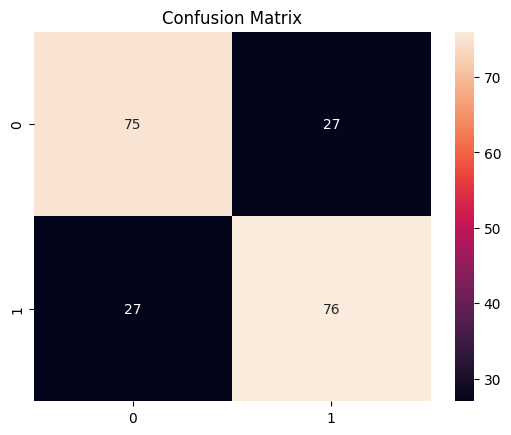

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

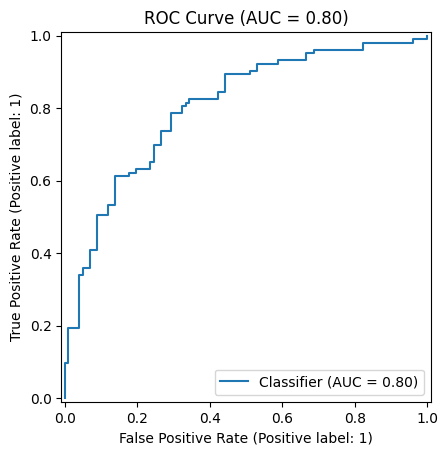

In [17]:
roc_auc = roc_auc_score(y_test, y_proba)
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()

## 📌 Insights

- Dataset was reduced to 5 key features for simplicity  
- Categorical values were converted into numeric format  
- Logistic Regression achieved good performance  
- Confusion matrix and ROC curve show model effectiveness  

## ✅ Conclusion

This project successfully demonstrates heart disease prediction using a simplified dataset and machine learning techniques.